In [1]:
import pathlib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from napari_ndev import PlateMapper

sns.set_theme()
theme_dict = sns.plotting_context('notebook').copy()
so.Plot.config.theme.update(theme_dict)

plt.rcParams["svg.fonttype"] = "none"

In [82]:
data_dir = pathlib.Path(r'./Data')

raw_data = pd.read_csv(data_dir / 'area_intensity_3.csv')

# get information from the filename
# prior to the letters 'HIC' is a 1-3 digit number that represents the age
raw_data['HIC'] = raw_data['file'].str.extract(r'(\d{1,3})HIC')
raw_data = raw_data.sort_values(by=['HIC'])
# prior to the .czi at the end of the file is a 2-3 digit number that represents the experiment
# the pattern is like 'obl 02.czi'
# raw_data['exp'] = raw_data['file'].str.extract(r'obl (\d{2,3})')
# raw_data['exp_id'] = raw_data['HIC'] + '_' + raw_data['exp']
# print(raw_data.exp_id.unique())

raw_data['well'] = raw_data['scene'].str.extract(r'-(\w+)')

In [83]:
# Manually remove wells or other data according to discoveries made later
print(f'{len(raw_data)}: original # rows')
# Filter out rows if the 'file' containers 'VERSION 1'
raw_data = raw_data[~raw_data['file'].str.contains('VERSION 1')]
print(f'{len(raw_data)}: after removing 18HIC VERSION 1 # rows')

# Manually remove wells or other data according to discoveries made later
# Filter out rows if 'HIC'==48 and 'well'='F9'
raw_data = raw_data[~((raw_data['HIC'] == '48') & (raw_data['well'] == 'F9'))]
print(f'{len(raw_data)}: after removing HIC 48 F9 # rows')
# Filter out HIC96 and E9
raw_data = raw_data[~((raw_data['HIC'] == '96') & (raw_data['well'] == 'E9'))]
print(f'{len(raw_data)}: after removing HIC 96 E9 # rows')


666335: original # rows
586985: after removing 18HIC VERSION 1 # rows
522776: after removing HIC 48 F9 # rows
477403: after removing HIC 96 E9 # rows


## TODO: 8/19/24 SOME ROWS ARE DUPLICATED
I currently see no pattern, its only certain scenes. Perhaps these are duplicated in the metadata of the images?

## FIXED DUPLICATED ROWS
- fixed 8/20/2024. Found that it is an issue of the metadata in images having replicate names for scenes, is this a new issue? Will need to check old images. Not sure how this is possible. 

In [84]:
print(len(raw_data))
keys = ['file', 'scene_id', 'ROI_label', 'description']
raw_data.sort_values(by=keys, inplace=True)
raw_duplicates = raw_data[raw_data.duplicated(subset=keys)]
# print(raw_duplicates.sum())
# raw_data[raw_duplicates].head()
print(len(raw_duplicates))
raw_duplicates

# return the unique file + scene combinations that are duplicated
scene_duplicates = raw_duplicates.groupby(['file','scene']).size().reset_index(name='count')
scene_duplicates

# # drop description from key to check for duplicates
# scene_duplicates = raw_duplicates[raw_duplicates['description'] == 'dapi_class_on_morph']
# scene_duplicates

477403
0


,file,scene,count


## Combine Raw Data with Known Treatment Map

In [85]:
# Plate Map Setup
treatments = {
    'chelation':{
        'Control': ['B1:C12'],
        '50uM DFP': ['D1:E12'],
        '100uM DFP': ['F1:G12'],
        '100uM DFO': ['A1:A12', 'H1:H12'],
    },
}

plate = PlateMapper(96)
plate.assign_treatments(treatments)
plate_df = plate.plate_map

for tx in treatments:
    display(plate.get_styled_plate_map(tx))

C:\Users\timmo\napari-ndev\src\napari_ndev\_plate_mapper.py:167: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  self.plate_map_pivot.style.applymap(get_background_color)


Column,1,2,3,4,5,6,7,8,9,10,11,12
Row,,,,,,,,,,,,
A,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO
B,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control
C,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control,Control
D,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP
E,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP,50uM DFP
F,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP
G,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP,100uM DFP
H,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO,100uM DFO


In [86]:
merged_df = pd.merge(raw_data, plate_df, how='left', left_on='well', right_on='Well ID')
merged_df = merged_df.drop(columns=['Row', 'Column', 'Well ID'])

# move last 5 columns (from plate map) to the front
cols = merged_df.columns.tolist()
cols = cols[-3:] + cols[:-3]
merged_df = merged_df[cols]

# for the categories use a list of the chelation treatment keys
merged_df['chelation'] = pd.Categorical(
    merged_df['chelation'],
    categories=list(treatments['chelation'].keys()),
    ordered=True
)

# Check for duplicates
duplicates = merged_df[merged_df.duplicated()]
print(f"Number of duplicate rows: {len(duplicates)}")

# keys = ['chelation', 'HIC', 'well', 'file', 'scene_id', 'ROI_label', 'description']
# # show duplicated rows
# duplicated_rows = merged_df[merged_df.duplicated(subset=keys, keep=False)]
# print(f"\nNumber of duplicated rows (specific columns): {len(duplicated_rows)}")
# duplicated_rows

Number of duplicate rows: 0


## Specifically Investigating Individual Neurons

In [87]:
morph_df = merged_df.loc[merged_df['mask_image'] == 'morph_label'].copy()
morph_df.sort_values(by='chelation', inplace=True)
# determine a new column 'cell_type', when grouping by file and scene and ROI_label, when 'intensity_image' is 'dapi_class'
# what the MAX, MEAN, INTETGRATED_INTENSITY values are

# Filter the DataFrame for 'dapi_class'
dapi_class_df = morph_df[morph_df['intensity_image'] == 'dapi_class'].copy()

# Define a function to determine the neuron type for each row
def determine_neuron_type(row):
    if row['MAX'] == 1 and row['INTEGRATED_INTENSITY'] == 1:
        return 'live cell'
    elif row['MAX'] == 2 and row['INTEGRATED_INTENSITY'] == 2:
        return 'dead cell'
    if row['MAX'] == 3 and row['INTEGRATED_INTENSITY'] == 3:
        return 'debris'
    elif row['INTEGRATED_INTENSITY'] == 0:
        return 'fragment'

    elif row['MAX'] >= 1 and row['INTEGRATED_INTENSITY'] > 1:
        return 'cluster'
    else:
        return None

# Apply the function row-wise to the filtered DataFrame
dapi_class_df.loc[:,'cell_type'] = dapi_class_df.apply(determine_neuron_type, axis=1)

# Group by 'file', 'scene', and 'ROI_label' and aggregate the 'cell_type'
cell_type = dapi_class_df.groupby(
    ['file', 'scene_id', 'ROI_label', 'chelation', 'HIC'],
    observed=True
)['cell_type'].first().reset_index()

# print the number of each neuron type
print(cell_type['cell_type'].value_counts())

# print file and scenes with 'debris'
print('images with debris:')
print(cell_type[cell_type['cell_type'] == 'debris'][['file', 'scene_id']])

cell_type
live cell    796
fragment     367
cluster      135
debris         4
dead cell      1
Name: count, dtype: int64
images with debris:
                                                  file       scene_id
32   2024-08-07 25x 18HIC VERSION 2 NCOA4 647 FT 56...     11_9_P8-A9
40   2024-08-07 25x 18HIC VERSION 2 NCOA4 647 FT 56...   14_13_P13-B9
41   2024-08-07 25x 18HIC VERSION 2 NCOA4 647 FT 56...   14_13_P13-B9
794  2024-08-07 25x 72HIC NCOA4 647 FT 568 PHALL 48...  105_104_P6-H9


### Manually check each scene identified as a bad image:
1. 18HIC v1/v2 P13-B9: weird cell debris
2. 18HIC V2 P8-A9: One out of focus cell, what I would suggest is correctly, marked as a bad cell, others are ok
3. P12-F9: Very crummy image, with lots of fragments, no DAPI -- F9's are now removed becaus the well was bad
4. P6-H9: 

### Plot the number and type captured by each image

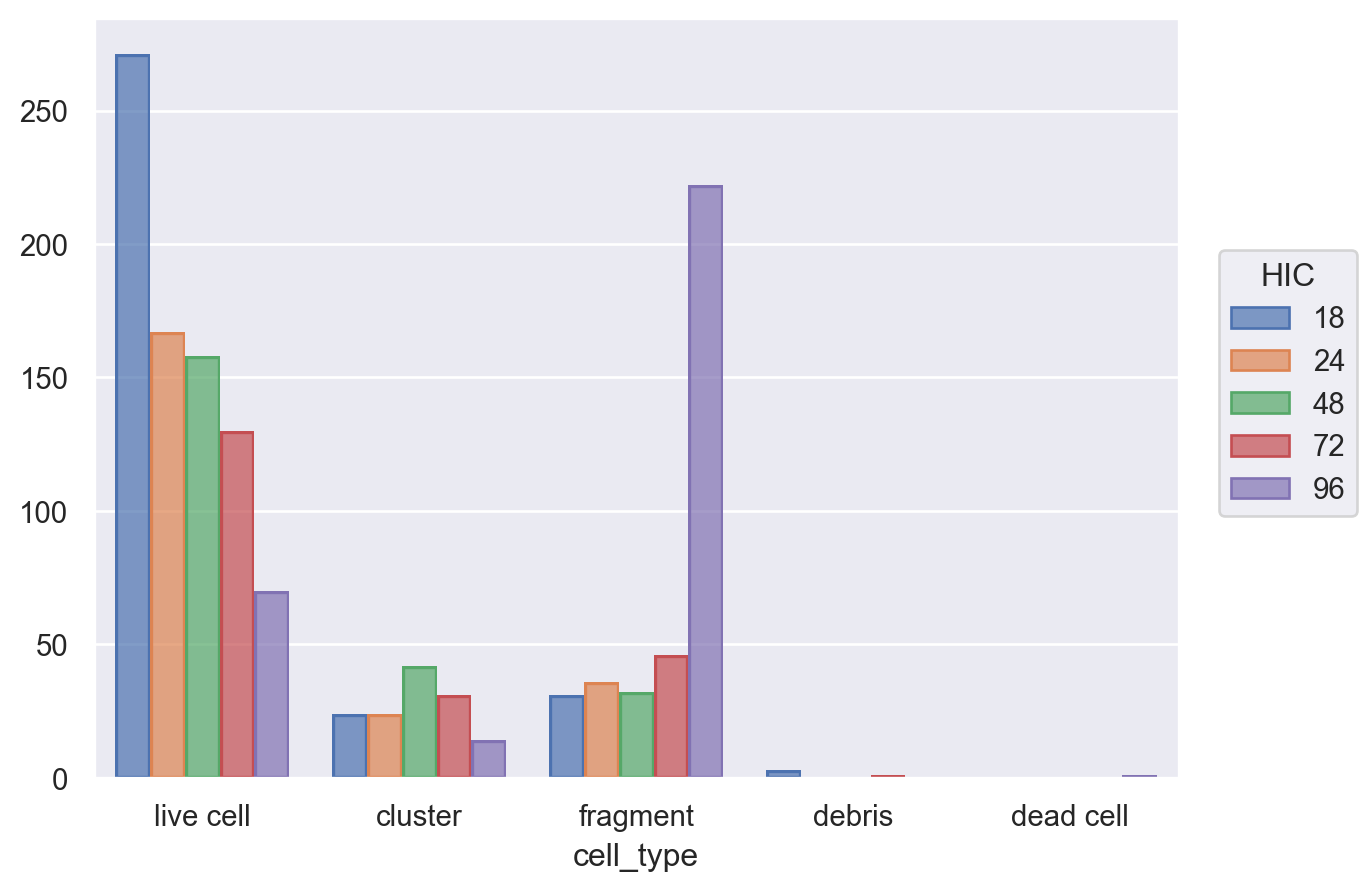

In [88]:
# plot the number of each neuron type for each chelation and HIC
(
    so.Plot(data=cell_type, x='cell_type',color='HIC')
    .add(so.Bar(), so.Hist(), so.Dodge())
)

In [89]:
# now, add the 'cell_type' value to morph_df
live_morph_df = pd.merge(
    morph_df,
    cell_type,
    how='left',
    on=['file', 'scene_id', 'ROI_label', 'chelation', 'HIC']
)
live_morph_df

# filter out any rows where 'cell_type' is not 'live cell'
live_morph_df = live_morph_df[live_morph_df['cell_type'] == 'live cell']

# sort by 'chelation' and 'HIC'
live_morph_df.sort_values(by=['chelation', 'HIC'], inplace=True)

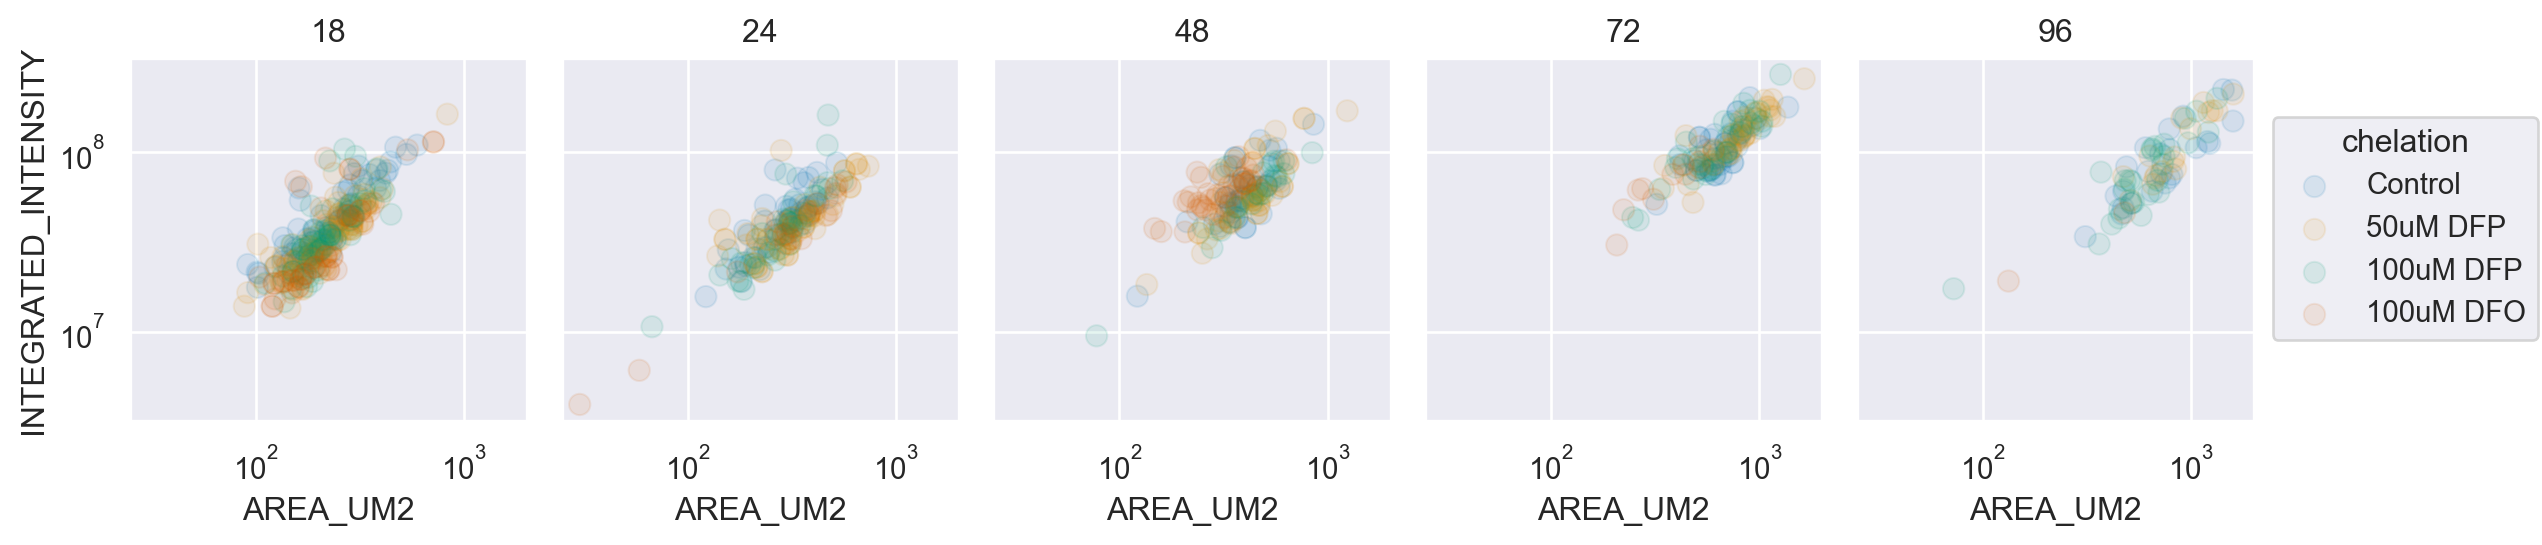

In [90]:
# plot the 'area' and 'integrated_intensity' for each 'chelation' and 'HIC'
# of description 'ftn_area_on_morph'
plot_df = live_morph_df[live_morph_df['description'] == 'ftn_intensity_on_morph']
(
    so.Plot(data=plot_df, x='AREA_UM2', y='INTEGRATED_INTENSITY', color='chelation')
    .facet('HIC')
    .scale(
        color='colorblind',
        y='log',
        x='log'
    )
    .add(so.Dots(pointsize=8, alpha=0.1, fillalpha=0.1))
    # .add(so.Line(), so.PolyFit(1))
    .layout(size=(12,3))
)

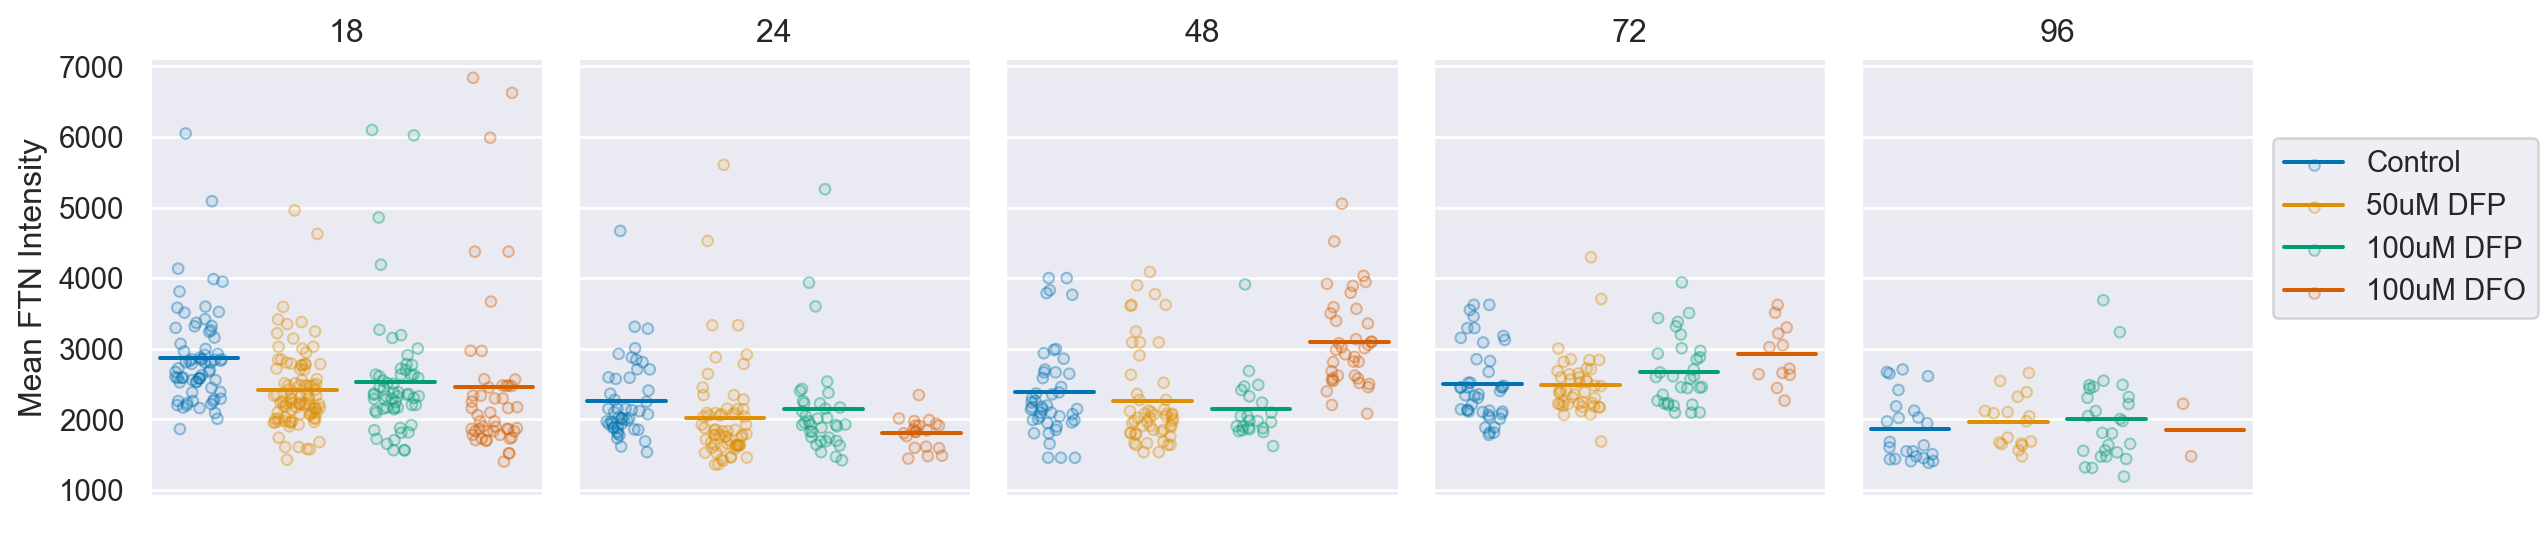

In [91]:
# intensity of Ferritin
plot_data = live_morph_df[live_morph_df['description'] == 'ftn_intensity_on_morph']
(
    so.Plot(data=plot_data, y='MEAN', x='chelation', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .add(so.Dots(alpha=0.4, fillalpha=0.1), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(12,3))
    .theme({'xtick.labelcolor': 'white', 'xtick.labelsize': 0})
    .label(
        x=None,
        y='Mean FTN Intensity',
        color=None
    )
)

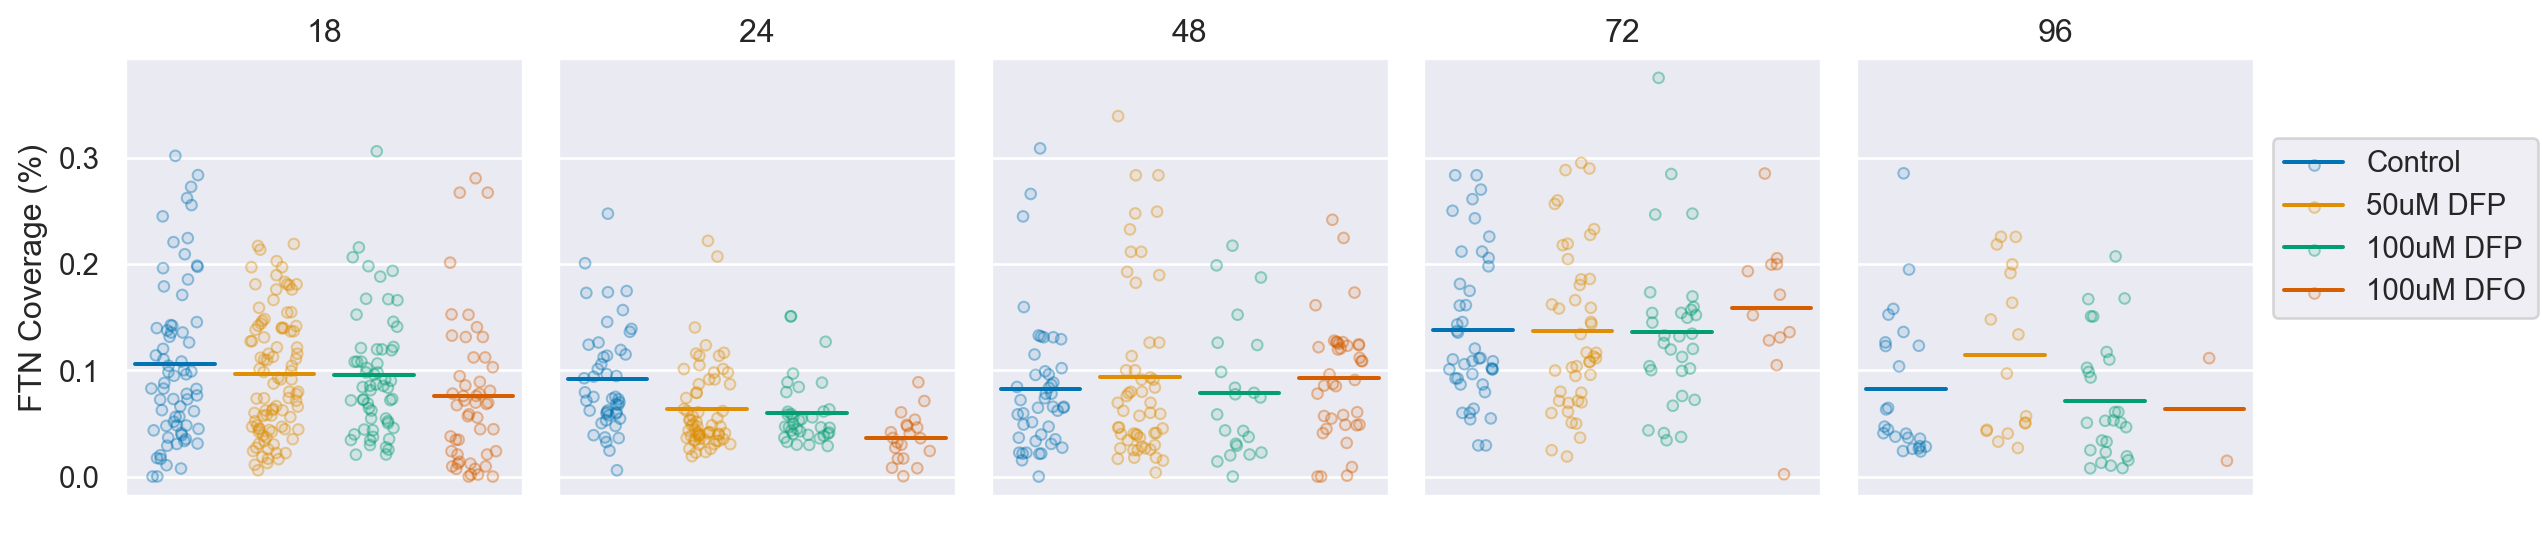

In [92]:
# get 'perc_coverage' by looking at all the 1s in the binary mask over the cell area (MEAN)
plot_df = live_morph_df[live_morph_df['description'] == 'ftn_area_on_morph']
(
    so.Plot(data=plot_df, y='MEAN', x='chelation', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .add(so.Dots(alpha=0.4, fillalpha=0.1), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(12,3))
    .theme({'xtick.labelcolor': 'white', 'xtick.labelsize': 0})
    .label(
        x=None,
        y='FTN Coverage (%)',
        color=None
    )
)

## Per Cell Analysis
1. Need to match ferritin labels to neuron morph. I think the way to do that is to have the mask image be ferritin_label, but somehow match that ferritin label to which neuron its on? I thinkI may need a column yet that I don't have.... 
Then take the morph_label for each given ROI_label and distribute to a new column called Neuron label for all the rois of ftn or ncoa4

In [103]:
def merge_morph_label(df, morph_id, intens_id, keys, cell_df):
    morph_df = df.loc[df['description'] == morph_id].copy()
    print(f'objects in morph_df: {len(morph_df)}')
    morph_df.sort_values(by=keys, inplace=True)
    morph_df.rename(columns={'MAX': 'morph_label'}, inplace=True)

    intens_df = df.loc[df['description'] == intens_id].copy()
    print(f'objects in intens_df: {len(intens_df)}')

    # merge the two DataFrames
    merged_df = pd.merge(
        intens_df,
        morph_df[keys + ['morph_label']],
        how='outer',
        on=keys
    )
    print(f'objects in merged_df: {len(merged_df)}')

    morph_type = cell_df.rename(
        columns={'cell_type': 'morph_type', 'ROI_label': 'morph_label'},
        inplace=False
    ).copy()

    # remove ROI_label from keys and add 'morph_label'
    merge_keys = keys.copy()
    merge_keys.remove('ROI_label')
    merge_keys.append('morph_label')

    # merge the 'morph_type' column to the merged DataFrame
    morph_merged_df = pd.merge(
        merged_df,
        morph_type,
        how='left',
        on=merge_keys
    )
    print(f'objects in final df: {len(merged_df)}')

    return morph_merged_df


## START HERE
TODO: Fix duplicating the merged columns, or something

In [105]:
# ftn
merged_ftn_df = merge_morph_label(
    merged_df,
    'morph_label_on_ftn_label',
    'ftn_intensity_on_ftn_label',
    ['file', 'scene_id', 'ROI_label', 'chelation', 'HIC'],
    cell_type
)

merged_ftn_df = merged_ftn_df[merged_ftn_df['morph_type'] == 'live cell']
print(f'objects in merged_ftn_df: {len(merged_ftn_df)}')

objects in morph_df: 132912
objects in intens_df: 132912
objects in merged_df: 132912
objects in final df: 132912
objects in merged_ftn_df: 65914


In [106]:
# ncoa4
merged_ncoa4_df = merge_morph_label(
    merged_df,
    'morph_label_on_ncoa4_label',
    'ncoa4_intensity_on_ncoa4_label',
    ['file', 'scene_id', 'ROI_label', 'chelation', 'HIC'],
    cell_type
)

merged_ncoa4_df = merged_ncoa4_df[merged_ncoa4_df['morph_type'] == 'live cell']
print(f'objects in merged_ncoa4_df: {len(merged_ncoa4_df)}')




objects in morph_df: 101821
objects in intens_df: 101821
objects in merged_df: 101821
objects in final df: 101821
objects in merged_ncoa4_df: 45557


## Start here

## Convert to functions, then do for NCOA4

C:\Users\timmo\AppData\Local\Temp\ipykernel_13052\4272922162.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(30))


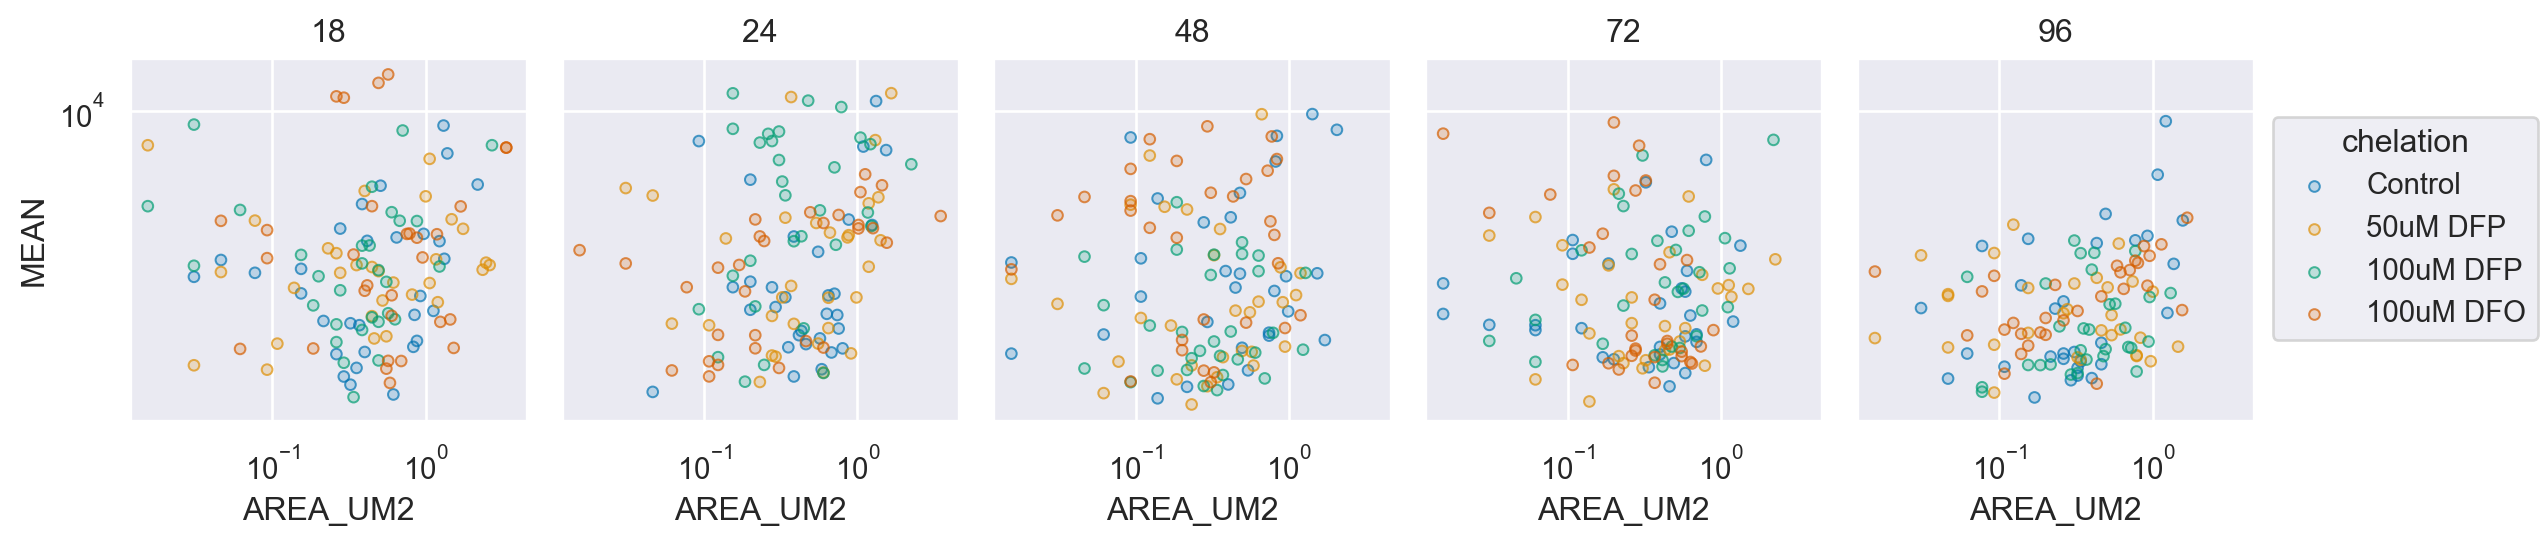

In [107]:
# plot on 100 random rows from each HIC and chelation group
plot_df = (
    merged_ftn_df
    .groupby(['HIC', 'chelation'], observed=True)
    .apply(lambda x: x.sample(30))
    .reset_index(drop=True)
)

(
    so.Plot(data=plot_df, x='AREA_UM2', y='MEAN', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .scale(y='log', x='log')
    .add(so.Dots(alpha=0.7))
    .layout(size=(12,3))
)

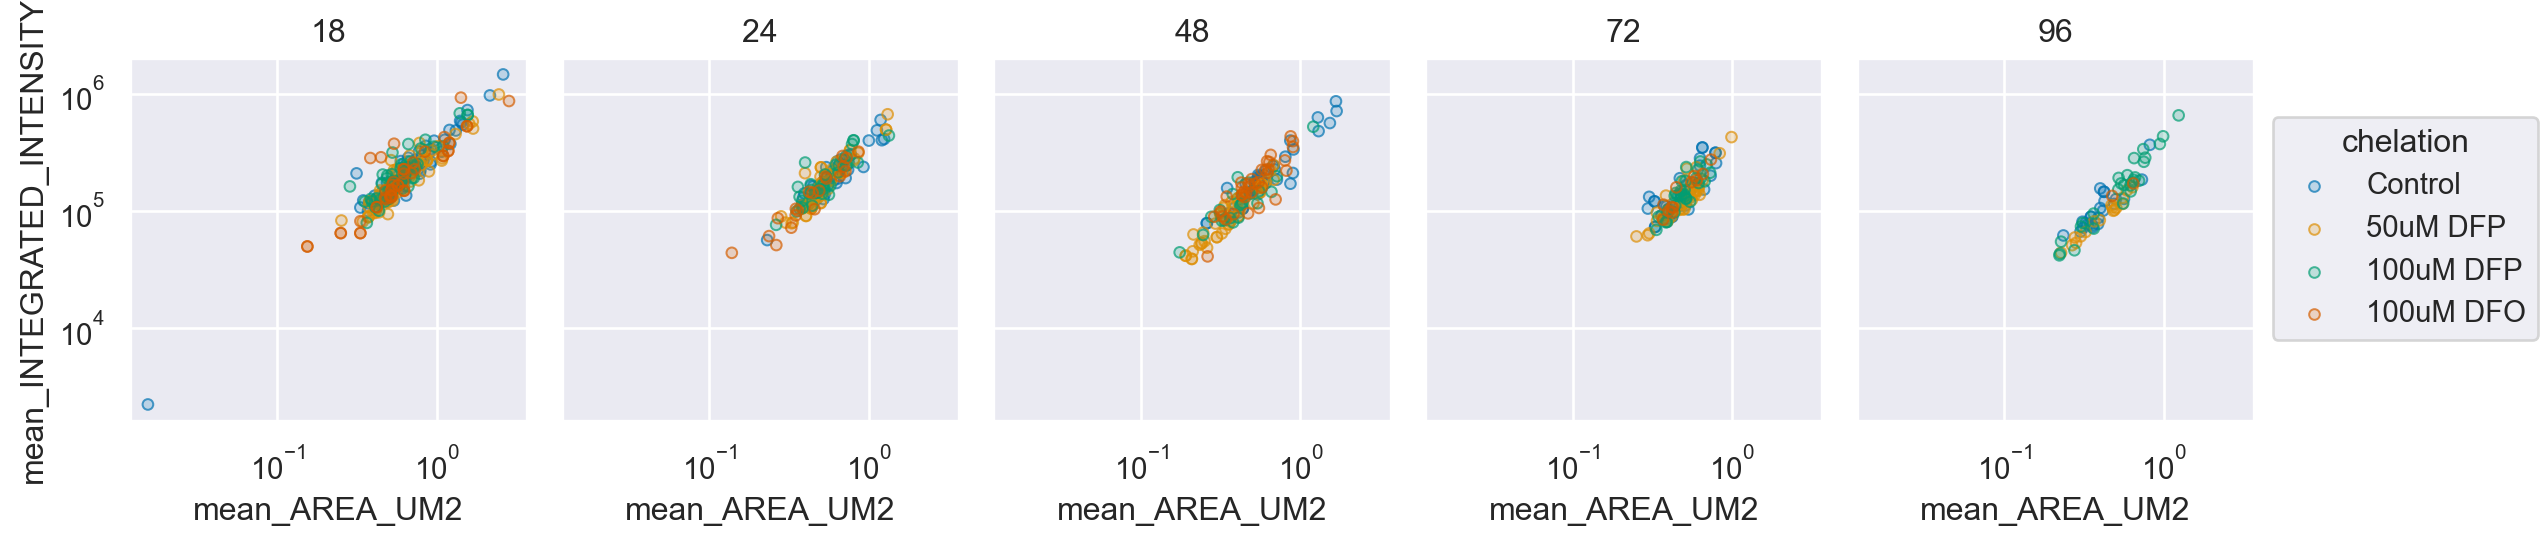

In [108]:
# get the average 'MEAN' and 'AREA_UM2' for each 'chelation', 'HIC', and 'morph_label'
plot_df = (
    merged_ftn_df
    .groupby(['HIC', 'chelation', 'scene_id', 'morph_label'], observed=True)
    .agg(
        mean_MEAN=('MEAN', 'mean'),
        mean_INTEGRATED_INTENSITY=('INTEGRATED_INTENSITY', 'mean'),
        mean_AREA_UM2=('AREA_UM2', 'mean'),
        sum_AREA_UM2=('AREA_UM2', 'sum'),
        sum_INTEGRATED_INTENSITY=('INTEGRATED_INTENSITY', 'sum'),
        puncta_count=('MEAN', 'count')
    )
    .reset_index()
)

(
    so.Plot(data=plot_df, x='mean_AREA_UM2', y='mean_INTEGRATED_INTENSITY', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .scale(y='log', x='log')
    .add(so.Dots(alpha=0.7))
    .layout(size=(12,3))
)


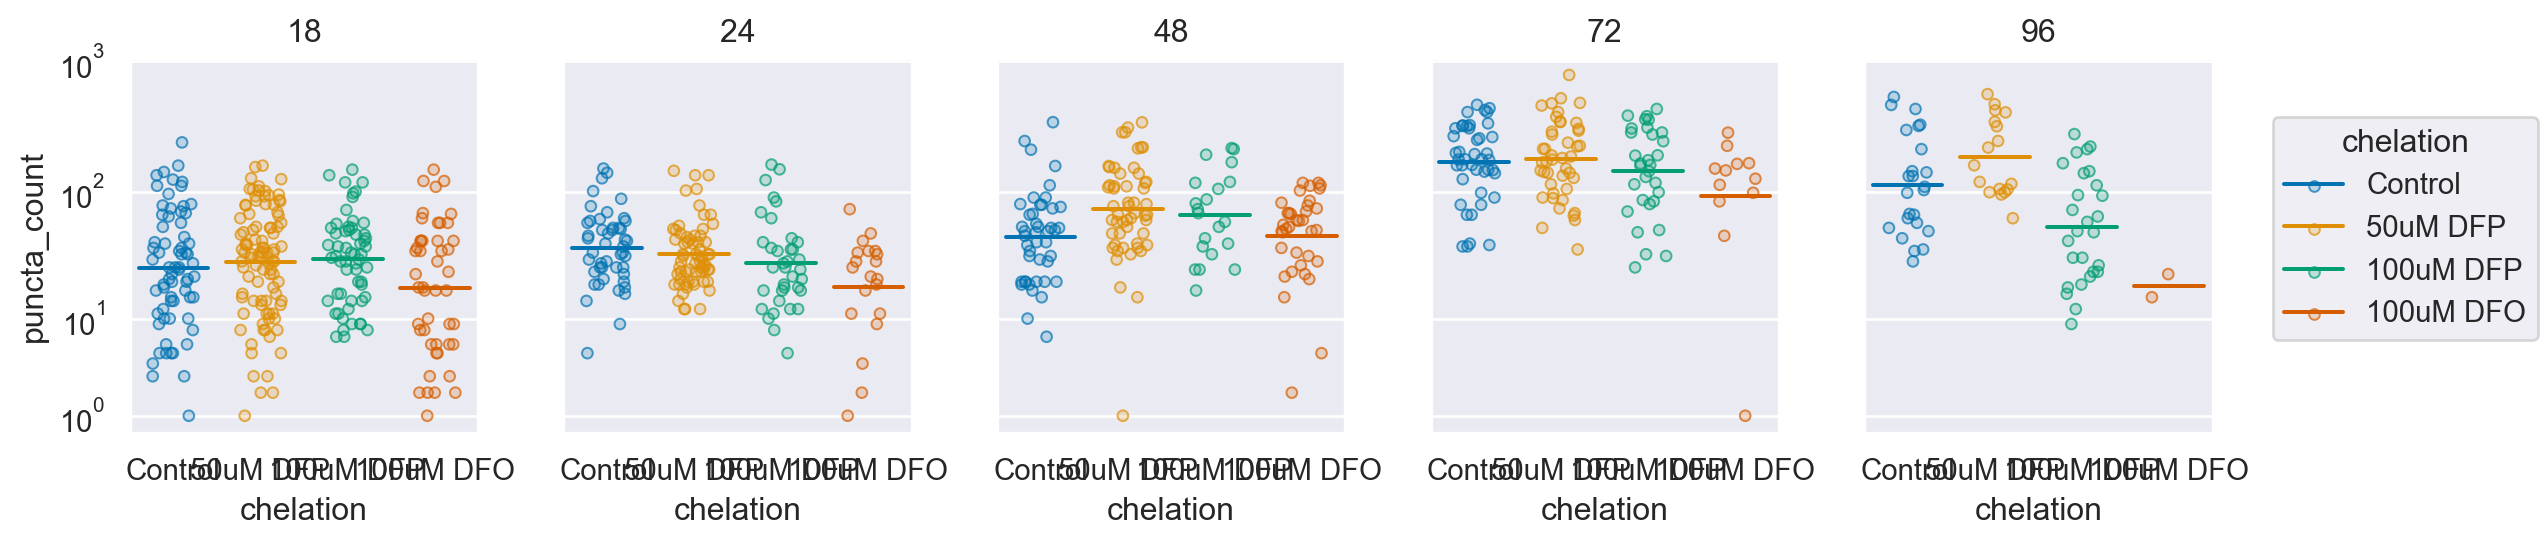

In [109]:
(
    so.Plot(data=plot_df, x='chelation', y='puncta_count', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .scale(y='symlog')
    .add(so.Dots(alpha=0.7), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(12,3))
)

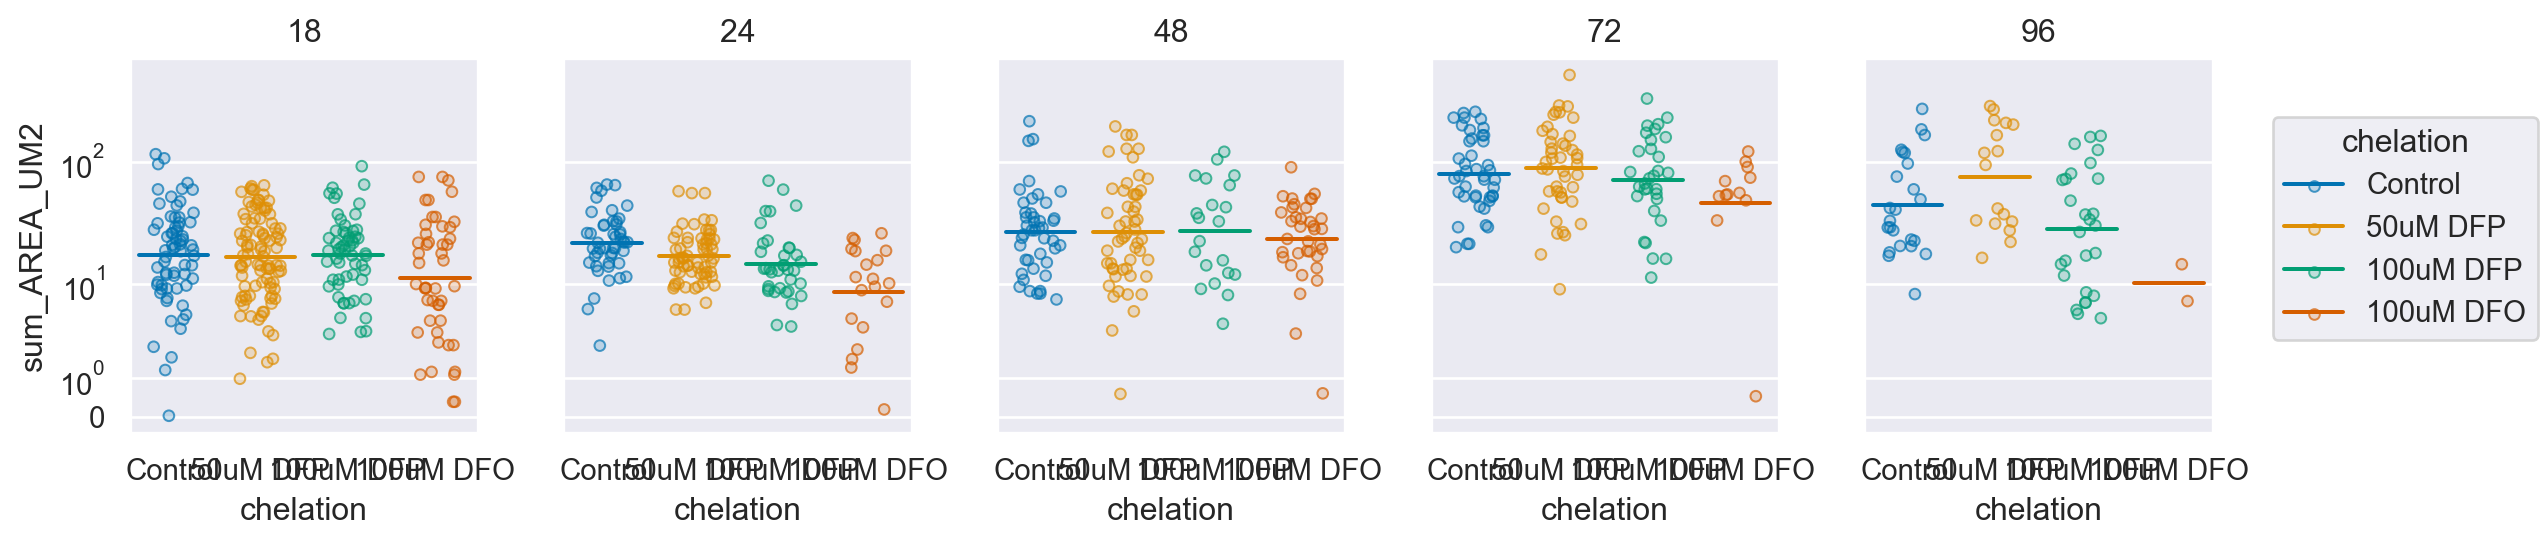

In [110]:
(
    so.Plot(data=plot_df, x='chelation', y='sum_AREA_UM2', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .scale(y='symlog')
    .add(so.Dots(alpha=0.7), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(12,3))
)

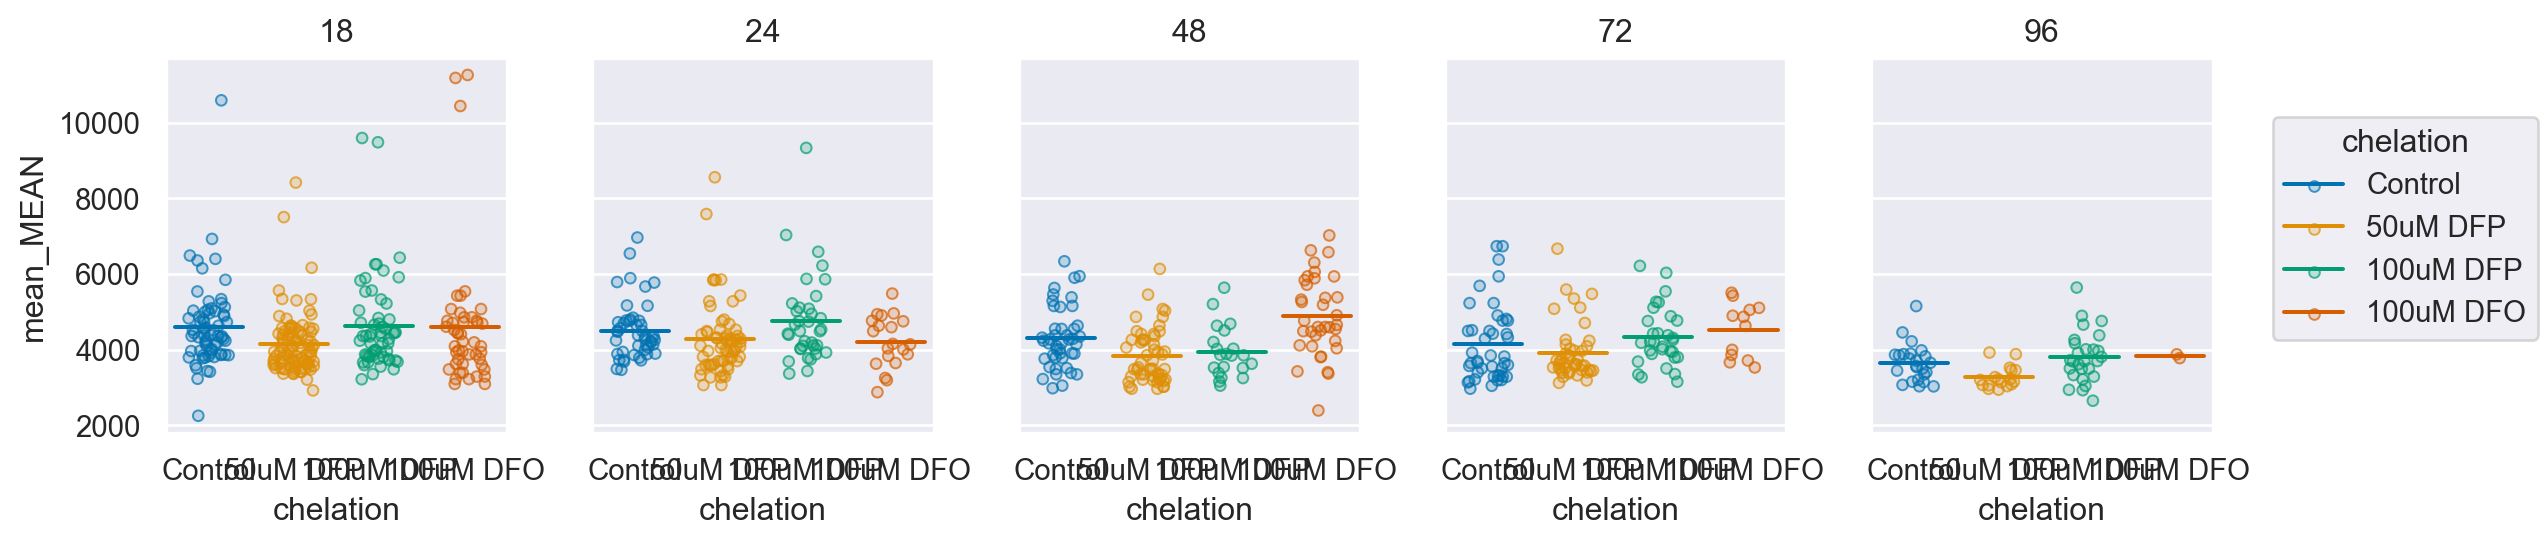

In [111]:
(
    so.Plot(data=plot_df, x='chelation', y='mean_MEAN', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .add(so.Dots(alpha=0.7), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(12,3))
)

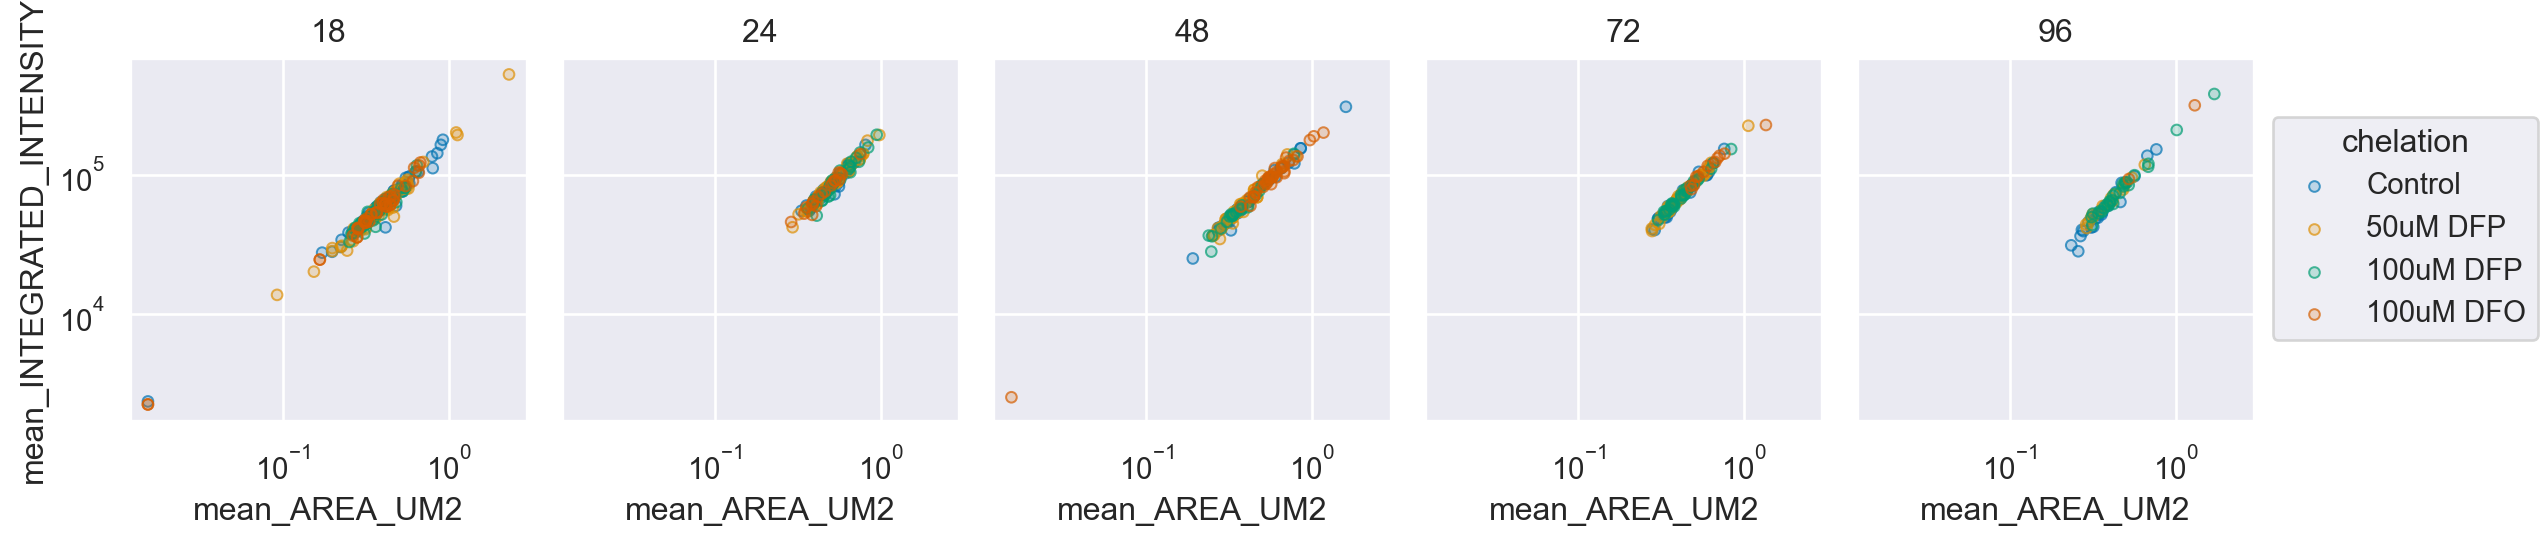

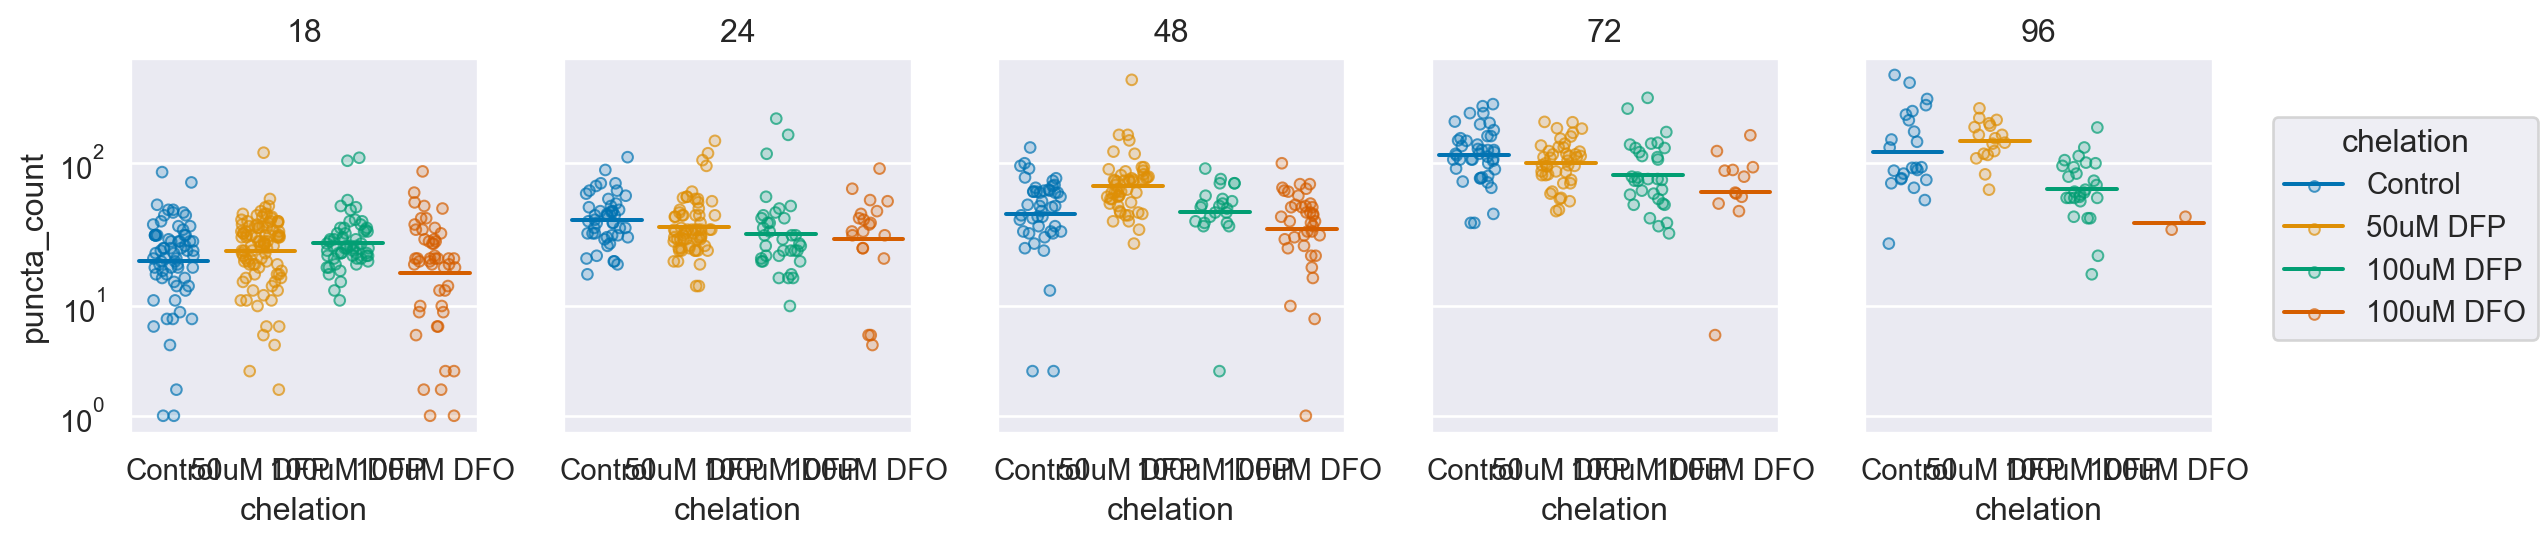

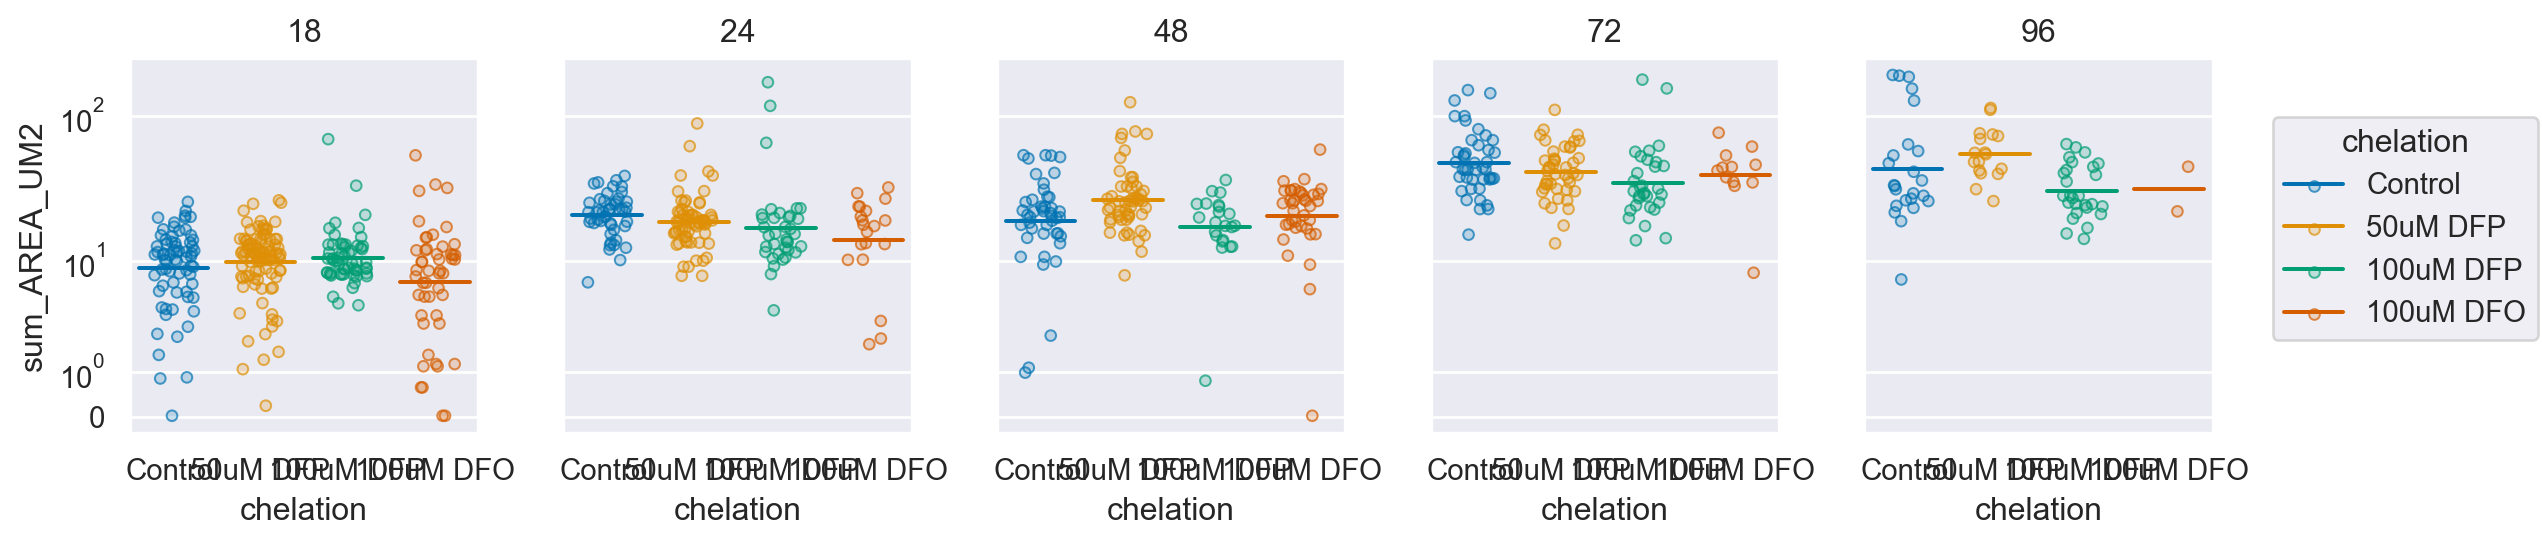

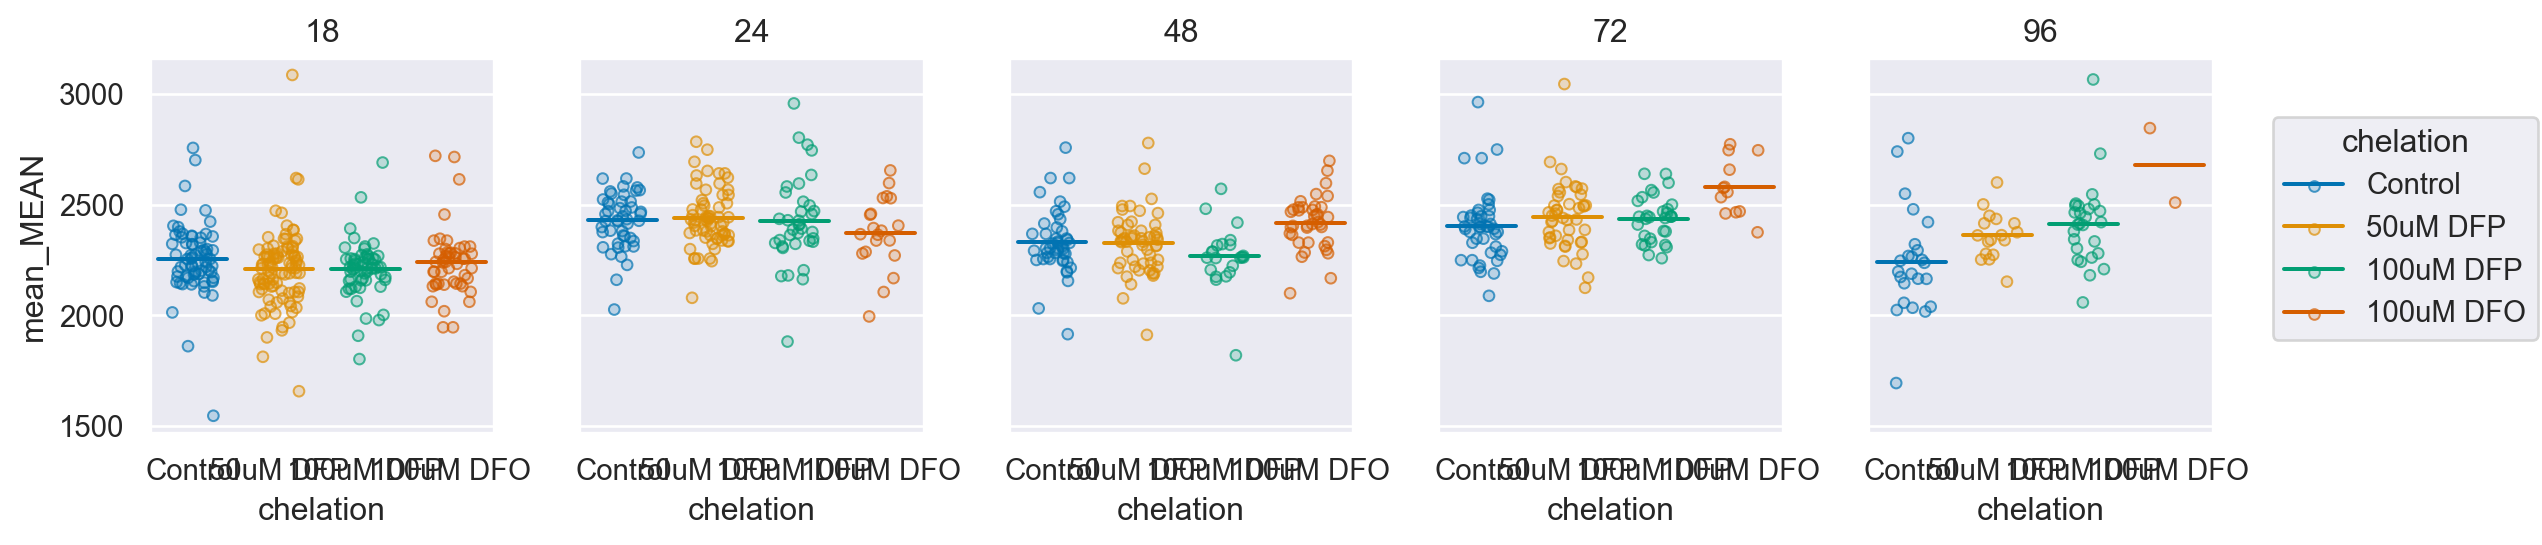

In [116]:
# get the average 'MEAN' and 'AREA_UM2' for each 'chelation', 'HIC', and 'morph_label'
plot_df = (
    merged_ncoa4_df
    .groupby(['HIC', 'chelation', 'scene_id', 'morph_label'], observed=True)
    .agg(
        mean_MEAN=('MEAN', 'mean'),
        mean_INTEGRATED_INTENSITY=('INTEGRATED_INTENSITY', 'mean'),
        mean_AREA_UM2=('AREA_UM2', 'mean'),
        sum_AREA_UM2=('AREA_UM2', 'sum'),
        sum_INTEGRATED_INTENSITY=('INTEGRATED_INTENSITY', 'sum'),
        puncta_count=('MEAN', 'count')
    )
    .reset_index()
)

p = (
    so.Plot(data=plot_df, x='mean_AREA_UM2', y='mean_INTEGRATED_INTENSITY', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .scale(y='log', x='log')
    .add(so.Dots(alpha=0.7))
    .layout(size=(12,3))
)
display(p)

p_count = (
    so.Plot(data=plot_df, x='chelation', y='puncta_count', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .scale(y='symlog')
    .add(so.Dots(alpha=0.7), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(12,3))
)
display(p_count)

p_sum_area = (
    so.Plot(data=plot_df, x='chelation', y='sum_AREA_UM2', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .scale(y='symlog')
    .add(so.Dots(alpha=0.7), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(12,3))
)
display(p_sum_area)

p_mean_mean = (
    so.Plot(data=plot_df, x='chelation', y='mean_MEAN', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .add(so.Dots(alpha=0.7), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(12,3))
)
display(p_mean_mean)


### Now NCOA4 intensity

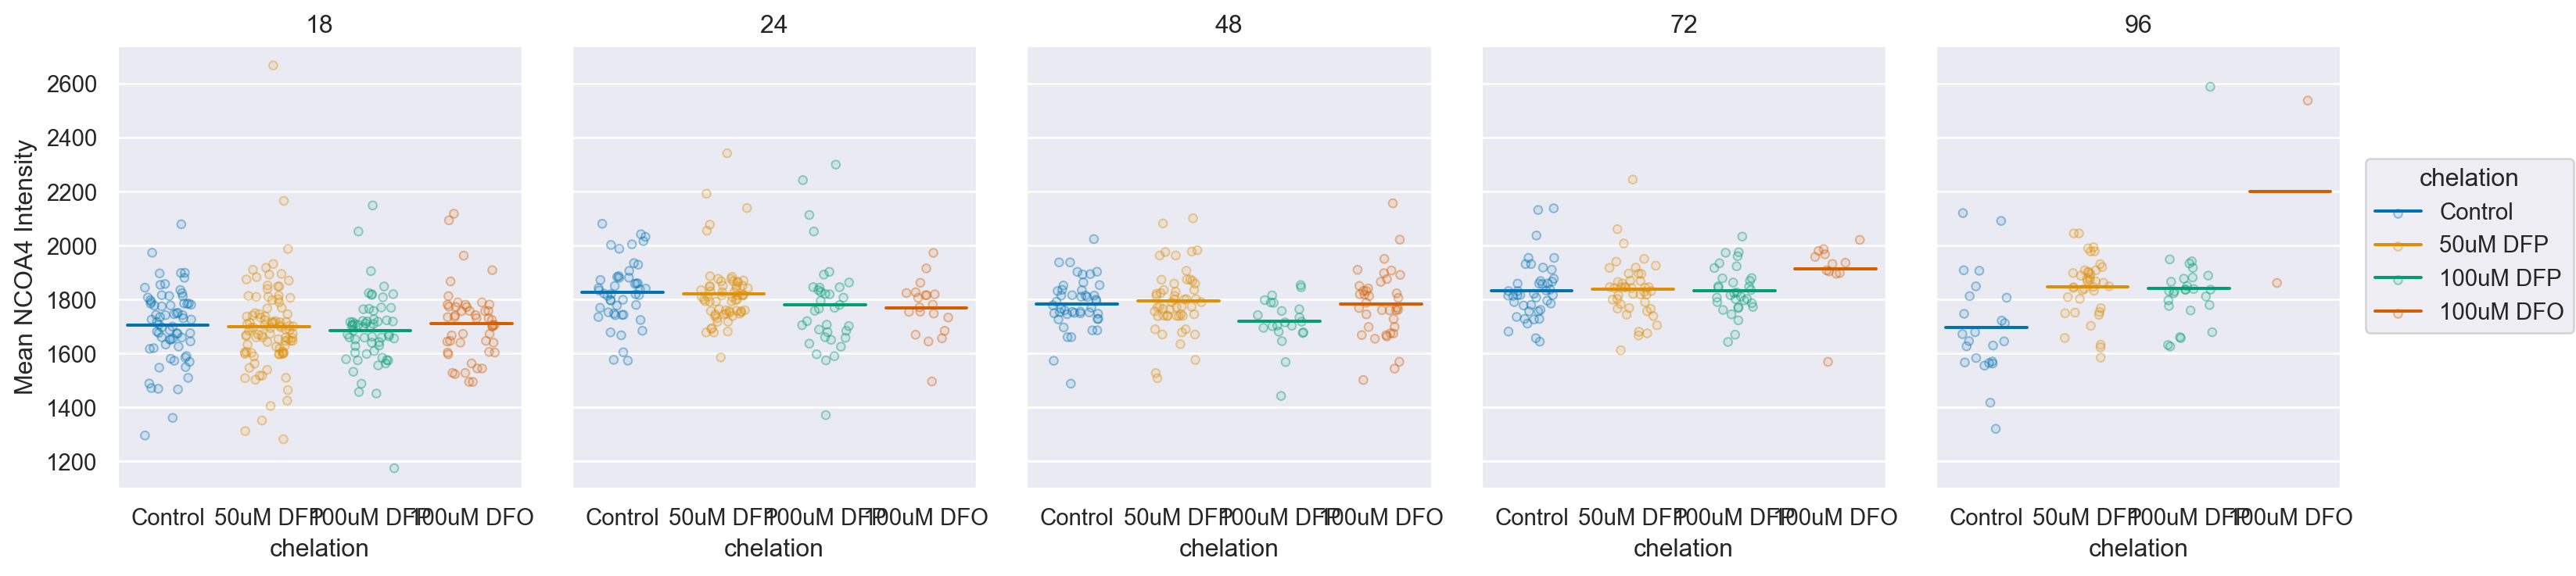

In [79]:
# Cell Area (measuring the morph area only)
plot_df = live_morph_df[live_morph_df['description'] == 'ncoa4_intensity_on_morph']
(
    so.Plot(data=plot_df, y='MEAN', x='chelation', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .add(so.Dots(alpha=0.4, fillalpha=0.1), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(16,4))
    .label(y='Mean NCOA4 Intensity')
)

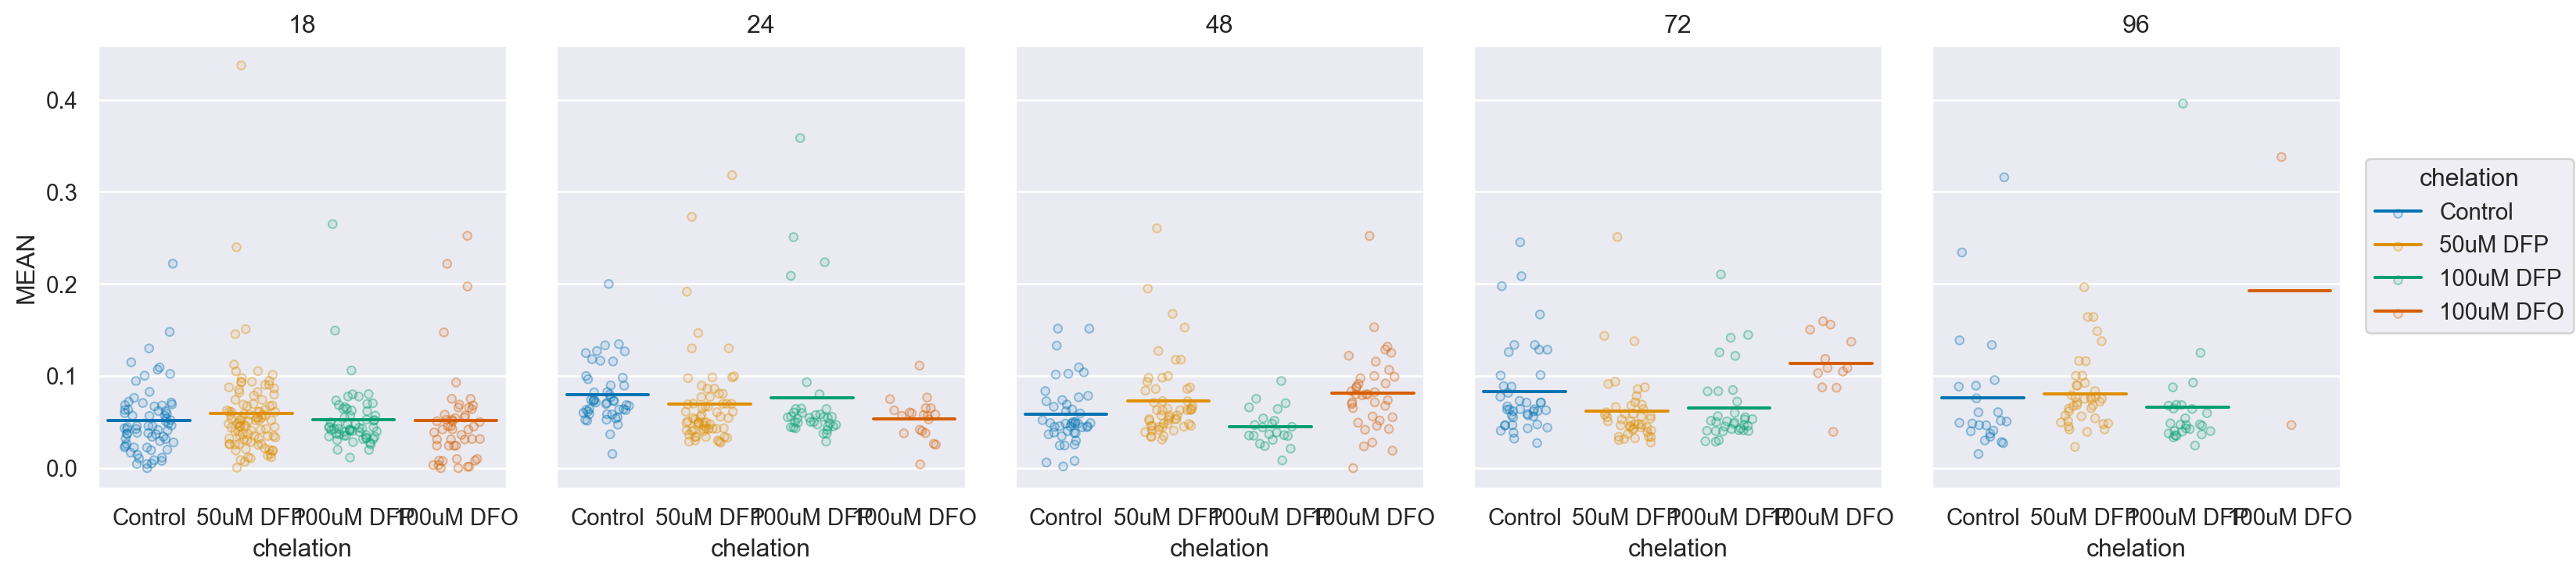

In [80]:
# percentage of cell covered by NCOA4
plot_df = live_morph_df[live_morph_df['description'] == 'ncoa4_area_on_morph']
(
    so.Plot(data=plot_df, y='MEAN', x='chelation', color='chelation')
    .facet('HIC')
    .scale(color='colorblind')
    .add(so.Dots(alpha=0.4, fillalpha=0.1), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .layout(size=(16,4))
)

### Cell morphology

In [ ]:
# combine the 'mean'

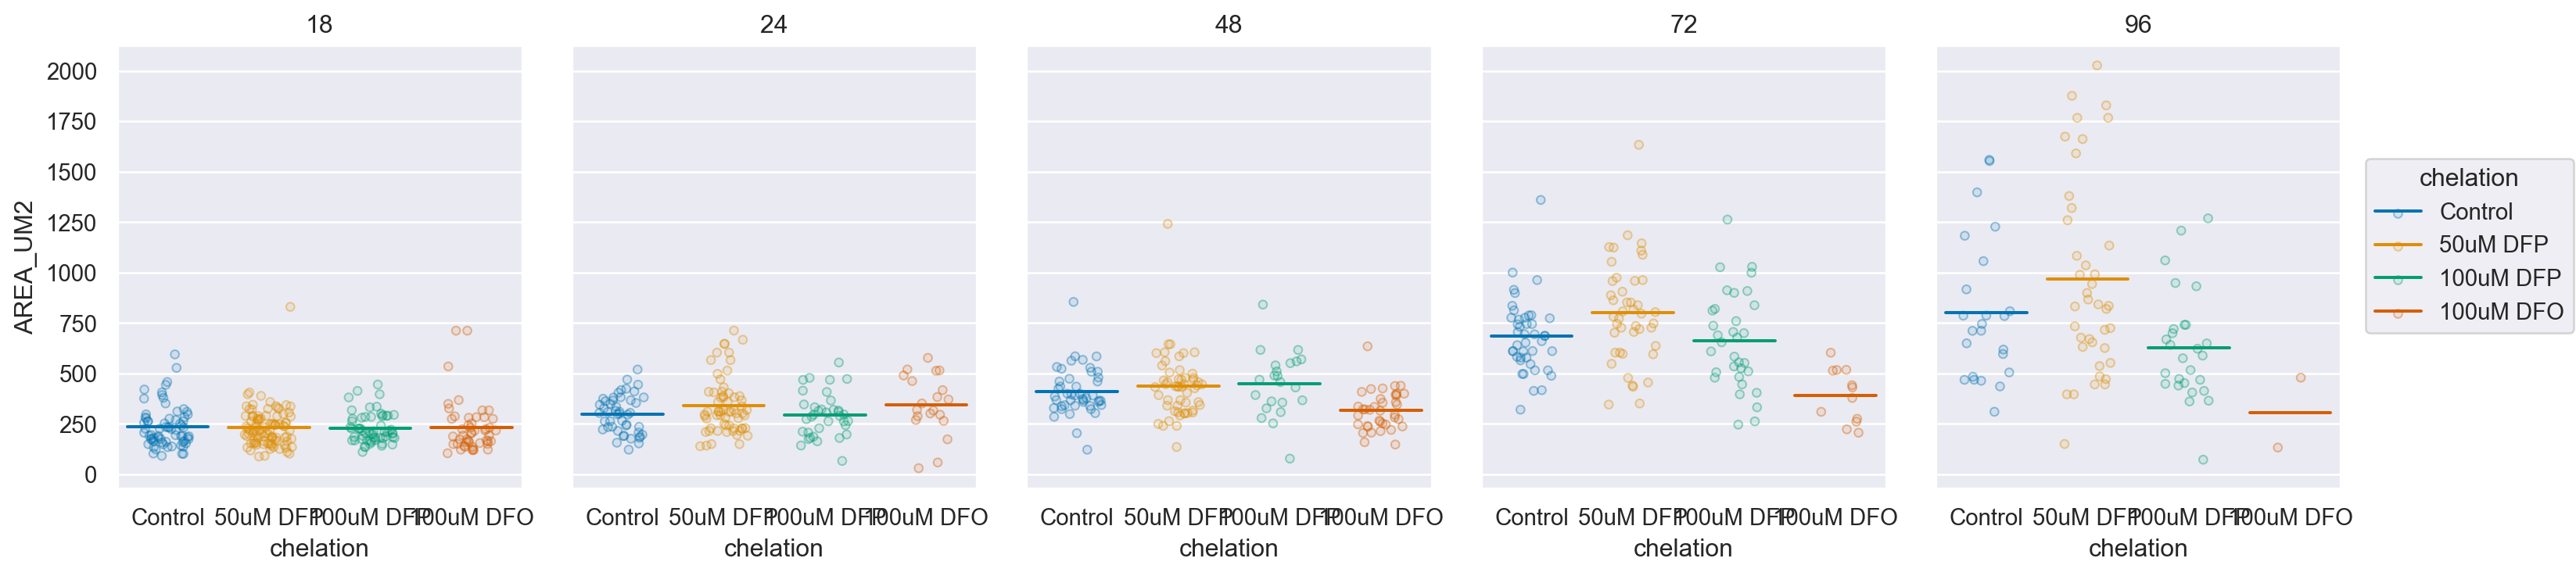

In [81]:
plot_df = live_morph_df[live_morph_df['description'] == 'ncoa4_intensity_on_morph']
(
    so.Plot(plot_df, x='chelation', y='AREA_UM2', color='chelation')
    .facet('HIC')
    .add(so.Dots(alpha=0.4,fillalpha=0.1), so.Jitter(width=0.6))
    .add(so.Dash(), so.Agg('mean'))
    .scale(
        color='colorblind',
    )
    .layout(size=(16,4))
)

In [11]:
# get from raw_data only where mask-image is ferritin and intensity-image is ferritin
raw_data = merged_df

ferritin_df = raw_data[
    (raw_data['mask_image'] == 'ferritin_label') & (raw_data['intensity_image'] == 'ferritin_intensity')
]
print(f'ferritin objects: {len(ferritin_df)}')
ferritin_on_dapi_df = raw_data[
    (raw_data['mask_image'] == 'ferritin_label') & (raw_data['intensity_image'] == 'ferritin_on_dapi_ext')
]
ferritin_on_dapi_df.rename(columns={'MAX': 'MAX_on_dapi'}, inplace=True)
print(f'ferritin_on_dapi objects: {len(ferritin_on_dapi_df)}')

keys = ['file', 'scene', 'ROI_label']
ferritin_merged_df = pd.merge(ferritin_df, ferritin_on_dapi_df[keys + ['MAX_on_dapi']], on=keys, how='left')
ferritin_merged_df = ferritin_merged_df[ferritin_merged_df['MAX_on_dapi'] > 0]

# sort by HIC
ferritin_merged_df['HIC'] = pd.Categorical(ferritin_merged_df['HIC'],ordered=True)
ferritin_merged_df.sort_values('HIC', inplace=True)

print(f'ferritin objects after removing zeros: {len(ferritin_merged_df)}')
ferritin_merged_df.sort_values('chelation', inplace=True)
ferritin_df.sort_values('chelation', inplace=True)

ferritin objects: 180245
ferritin_on_dapi objects: 0
ferritin objects after removing zeros: 0


C:\Users\timmo\AppData\Local\Temp\ipykernel_12272\1096348080.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ferritin_on_dapi_df.rename(columns={'MAX': 'MAX_on_dapi'}, inplace=True)
C:\Users\timmo\AppData\Local\Temp\ipykernel_12272\1096348080.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ferritin_df.sort_values('chelation', inplace=True)
